# Rag system

In [1]:
import os
import getpass

os.environ["GROQ_API_KEY"] = getpass.getpass("Groq API key: ")
print("Key set (hidden for security).")

Key set (hidden for security).


In [2]:

from typing import TypedDict, Literal, List

from langgraph.graph import StateGraph, START, END

from langchain_core.documents import Document

from langchain_core.vectorstores import InMemoryVectorStore

from langchain_groq import ChatGroq

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [3]:
documents = [
    Document(
        page_content=(
            "Machine Learning is a branch of Artificial Intelligence that "
            "enables computers to learn patterns from data and make predictions "
            "without being explicitly programmed."
        ),
        metadata={"source": "ml_basics.txt", "topic": "introduction"},
    ),
    Document(
        page_content=(
            "Supervised learning uses labeled data to train models. "
            "Common algorithms include Linear Regression, Decision Trees, "
            "and Random Forests."
        ),
        metadata={"source": "ml_basics.txt", "topic": "supervised_learning"},
    ),
    Document(
        page_content=(
            "Unsupervised learning works with unlabeled data to discover "
            "hidden patterns. Clustering algorithms such as K-Means are "
            "widely used for customer segmentation."
        ),
        metadata={"source": "ml_basics.txt", "topic": "unsupervised_learning"},
    ),
    Document(
        page_content=(
            "Feature engineering involves transforming raw data into meaningful "
            "features that improve model performance. Scaling and encoding are "
            "common preprocessing techniques."
        ),
        metadata={"source": "ml_basics.txt", "topic": "data_preprocessing"},
    ),
    Document(
        page_content=(
            "Model evaluation measures how well a machine learning model "
            "performs. Metrics such as Accuracy, Precision, Recall, and F1-Score "
            "are commonly used for classification tasks."
        ),
        metadata={"source": "ml_basics.txt", "topic": "evaluation"},
    ),
]

print(f"Created {len(documents)} documents.")
for i, doc in enumerate(documents):
    print(f"  Doc {i+1}: {doc.page_content[:60]}...")

Created 5 documents.
  Doc 1: Machine Learning is a branch of Artificial Intelligence that...
  Doc 2: Supervised learning uses labeled data to train models. Commo...
  Doc 3: Unsupervised learning works with unlabeled data to discover ...
  Doc 4: Feature engineering involves transforming raw data into mean...
  Doc 5: Model evaluation measures how well a machine learning model ...


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = InMemoryVectorStore(embedding=embeddings)
vector_store.add_documents(documents)

print("Knowledge base ready!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Knowledge base ready!


In [7]:
llm = ChatGroq(
    model_name="llama-3.3-70b-versatile"
)

In [9]:
class RAGstate(TypedDict):
    question : str
    documents : List[Document]
    answer : str

In [10]:
def retrieve(state: RAGstate) -> dict:
    'Retrieve the top-3 documents most relevant to the question.'
    print(f"[retrieve] Searching for: '{state['question']}'")
    docs = vector_store.similarity_search(state['question'], k=3)
    print(f'[retrieve] Found {len(docs)} document(s).')
    return {'documents': docs}

In [12]:
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ('system',
     'You are a helpful assistant. Use ONLY the context below to answer the '
     'question. If the context does not contain enough information, say '
     '"I don\'t know."'),
    ('human',
     'Context:\n{context}\n\nQuestion: {question}\n\nAnswer:'),
])

def generate(state: RAGstate) -> dict:
    'Generate an answer using the retrieved documents.'
    # Join all document texts into one context string
    context = '\n\n'.join(doc.page_content for doc in state['documents'])
    # Build and run the chain: prompt -> LLM -> string parser
    chain = RAG_PROMPT | llm | StrOutputParser()
    answer = chain.invoke({'context': context, 'question': state['question']})
    print(f'[generate] Answer: {answer[:120]}...')
    return {'answer': answer}

In [13]:
builder  =  StateGraph(RAGstate)

builder.add_node('retriver',retrieve)
builder.add_node('genrater',generate)

builder.add_edge(START,'retriver')
builder.add_edge('retriver','genrater')
builder.add_edge('genrater',END)



In [14]:
graph = builder.compile()

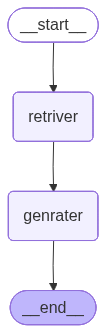

In [15]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [17]:
result = graph.invoke({'question': 'What is machine learinng'})

print('\n' + '='*60)
print('QUESTION:', result['question'])
print('='*60)
print('ANSWER:')
print(result['answer'])
print('='*60)

[retrieve] Searching for: 'What is machine learinng'
[retrieve] Found 3 document(s).
[generate] Answer: Machine Learning is a branch of Artificial Intelligence that enables computers to learn patterns from data and make pred...

QUESTION: What is machine learinng
ANSWER:
Machine Learning is a branch of Artificial Intelligence that enables computers to learn patterns from data and make predictions without being explicitly programmed.
